# Customer Investment Needs — Modeling

**Goal:** Train binary classifiers for each investment target, build an entropy-gated
soft-vote ensemble, and flag uncertain predictions for human review using KNN
neighbourhood disagreement.

**Inputs:** `processed_features.xlsx` — output of `0-DataPreprocessing.ipynb`

**Outputs:** `model_predictions.xlsx` — per-customer probabilities, ensemble predictions,
and review flags — consumed by `2_next_best_action_system_design.ipynb`

---

## Notebook Structure

1. Imports & Setup
2. Load Processed Data
3. Scaling  *(scaler fit on train only — see leakage note in §5)*
4. Train / Test Split
5. Distance Matrix Construction
6. Custom Scorers
7. Modeling
8. Entropy-Gated Ensemble
9. KNN Uncertainty Flagging
10. SHAP Explainability
11. Export

---
## 1. Imports & Setup

In [ ]:
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

import plots
import utilities
import models as model_module
from models import ModelFactory
from utilities import (
    display_results_table,
    display_tuning_results,
    plot_model_diagnostics,
    run_experiment,
    binary_entropy,
    split_by_entropy,
    evaluate_entropy_splits,
)

# Hot-reload during development
importlib.reload(plots)
importlib.reload(utilities)
importlib.reload(model_module)

sns.set_theme(style="darkgrid", context="notebook", palette="muted")
plt.rcParams.update({
    "figure.dpi":       110,
    "axes.titlesize":   12,
    "axes.labelsize":   10,
    "figure.facecolor": "#1a1a2e",
    "axes.facecolor":   "#16213e",
    "text.color":       "#e0e0e0",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#e0e0e0",
    "ytick.color":      "#e0e0e0",
})

SEED    = 42
TARGETS = ["IncomeInvestment", "AccumulationInvestment"]

---
## 2. Load Processed Data

Two sheets from `processed_features.xlsx`:
- `features` — engineered features
- `targets`  — two binary labels

In [12]:
input_path = "processed_features.xlsx"

feature_df = pd.read_excel(input_path, sheet_name="features", index_col=0)
targets_df = pd.read_excel(input_path, sheet_name="targets",  index_col=0)

print("features :", feature_df.shape)
print("targets  :", targets_df.shape)
print("\nClass balance:")
print(targets_df.mean().round(3))
feature_df.head()

features : (5000, 8)
targets  : (5000, 2)

Class balance:
IncomeInvestment          0.384
AccumulationInvestment    0.513
dtype: float64


,Age,FamilyMembers,FinancialEducation,RiskPropensity,Wealth_log,Income_log,IncomePerFamilyMember_log,Income_Wealth_Ratio_log
0,64,3,0.563402,0.582442,5.122047,5.048320,3.962466,0.656742
1,57,2,0.197647,0.396081,4.219891,4.228070,3.549398,0.697306
2,53,2,0.404948,0.407098,3.602428,3.398944,2.738659,0.593727
3,67,3,0.610428,0.332732,4.726979,4.620627,3.541516,0.640910
4,57,3,0.507142,0.501799,4.122068,4.141433,3.074125,0.703036


In [13]:
NUMERICAL_FEATURES   = feature_df.select_dtypes(include="number").columns.tolist()
CATEGORICAL_FEATURES = feature_df.select_dtypes(exclude="number").columns.tolist()

print("Numerical  :", NUMERICAL_FEATURES)
print("Categorical:", CATEGORICAL_FEATURES)

Numerical  : ['Age', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity', 'Wealth_log', 'Income_log', 'IncomePerFamilyMember_log', 'Income_Wealth_Ratio_log']
Categorical: []


---
## 3. Train / Test Split

Stratified 80/20 split applied **once** before any scaling.  Stratification
preserves class balance in both splits.

> **Leakage note:** The scaler is fit exclusively on `X_train_*` (§4).
> Distance-matrix construction (§5) also uses only the training features so that
> test-set geometry does not influence any upstream step.

In [14]:
income_series = targets_df["IncomeInvestment"]
accum_series  = targets_df["AccumulationInvestment"]

X_train_inc, X_test_inc, y_income_train, y_income_test = train_test_split(
    feature_df, income_series,
    test_size=0.2, random_state=SEED, stratify=income_series,
)

X_train_acc, X_test_acc, y_accum_train, y_accum_test = train_test_split(
    feature_df, accum_series,
    test_size=0.2, random_state=SEED, stratify=accum_series,
)

print(f"Income       — train: {len(X_train_inc):,}  test: {len(X_test_inc):,}")
print(f"Accumulation — train: {len(X_train_acc):,}  test: {len(X_test_acc):,}")

Income       — train: 4,000  test: 1,000
Accumulation — train: 4,000  test: 1,000


---
## 4. Scaling

`StandardScaler` is **fit on the training set only** and then applied to both
train and test.  Fitting on the full dataset before the split would leak test
statistics into training (mean/std of the test set would shift the training
distribution).

In [15]:
# =========================
# 1. SCALERS (separate per target)
# =========================
scaler_inc = StandardScaler()
scaler_acc = StandardScaler()

# =========================
# 2. INCOME SCALING
# =========================
X_train_inc_scaled = pd.DataFrame(
    scaler_inc.fit_transform(X_train_inc[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=X_train_inc.index
)

X_test_inc_scaled = pd.DataFrame(
    scaler_inc.transform(X_test_inc[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=X_test_inc.index
)

# add categorical features back
for col in CATEGORICAL_FEATURES:
    X_train_inc_scaled[col] = X_train_inc[col].values
    X_test_inc_scaled[col] = X_test_inc[col].values


# =========================
# 3. ACCUMULATION SCALING
# =========================
X_train_acc_scaled = pd.DataFrame(
    scaler_acc.fit_transform(X_train_acc[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=X_train_acc.index
)

X_test_acc_scaled = pd.DataFrame(
    scaler_acc.transform(X_test_acc[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=X_test_acc.index
)

# add categorical features back
for col in CATEGORICAL_FEATURES:
    X_train_acc_scaled[col] = X_train_acc[col].values
    X_test_acc_scaled[col] = X_test_acc[col].values


# =========================
# 4. SANITY CHECKS
# =========================
print("Income train means (should be ~0):")
print(X_train_inc_scaled[NUMERICAL_FEATURES].mean().round(3))

print("\nAccumulation train means (should be ~0):")
print(X_train_acc_scaled[NUMERICAL_FEATURES].mean().round(3))

Income train means (should be ~0):
Age                         -0.0
FamilyMembers               -0.0
FinancialEducation          -0.0
RiskPropensity              -0.0
Wealth_log                   0.0
Income_log                   0.0
IncomePerFamilyMember_log   -0.0
Income_Wealth_Ratio_log     -0.0
dtype: float64

Accumulation train means (should be ~0):
Age                          0.0
FamilyMembers                0.0
FinancialEducation          -0.0
RiskPropensity              -0.0
Wealth_log                  -0.0
Income_log                  -0.0
IncomePerFamilyMember_log    0.0
Income_Wealth_Ratio_log     -0.0
dtype: float64


---
## 5. Distance Matrix Construction

Built on **training features only** — the test set must not influence the
neighbourhood structure used later in the KNN uncertainty step.

> **Design note:** Feature scaling (§4) ensures no single variable dominates
> Euclidean distances.  Later stages may add feature weights to reflect
> financial relevance (e.g. risk propensity, income).

In [16]:
distance_matrix = pairwise_distances(X_train_inc_scaled, metric="euclidean")

print(f"Distance matrix shape : {distance_matrix.shape}")
print(f"Value range           : [{distance_matrix.min():.4f}, {distance_matrix.max():.4f}]")
print(f"Mean distance         : {distance_matrix.mean():.4f}")

assert np.allclose(np.diag(distance_matrix), 0, atol=1e-6), "Diagonal non-zero."
print("Diagonal check        : OK")

Distance matrix shape : (4000, 4000)
Value range           : [0.0000, 19.8986]
Mean distance         : 3.6979
Diagonal check        : OK


---
## 6. Custom Scorers

Standard accuracy ignores class imbalance.  Two alternatives:

1. **`constrained_recall_scorer`** — returns −1 if class-0 recall falls below a
   configurable floor; otherwise returns accuracy.
2. **`balanced_recall_accuracy`** — weighted blend:
   `α · recall(class=1) + (1−α) · accuracy` (professor's suggestion, `α=0.7`).

In [17]:
from sklearn.metrics import make_scorer, recall_score, accuracy_score


def constrained_recall_scorer(y_true, y_pred, recall_floor: float = 0.6):
    """
    Returns accuracy if class-0 recall >= recall_floor, else -1.
    Use make_scorer(constrained_recall_scorer) for sklearn CV.
    """
    recall_0 = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    if recall_0 < recall_floor:
        return -1.0
    return accuracy_score(y_true, y_pred)


def balanced_recall_accuracy(y_true, y_pred, alpha: float = 0.7):
    """
    Weighted blend: alpha * recall(class=1) + (1-alpha) * accuracy.
    """
    rec1 = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    acc  = accuracy_score(y_true, y_pred)
    return alpha * rec1 + (1 - alpha) * acc


constrained_scorer = make_scorer(constrained_recall_scorer)
balanced_scorer    = make_scorer(balanced_recall_accuracy)

---
## 7. Modeling

Each `run_experiment` call:
1. Optionally tunes hyperparameters on `X_train` only
2. Runs stratified CV on `X_train`; evaluates once on `X_test`
3. Fits `trained_model` on all of `X_train` for inference
4. Returns `(model, results, y_prob, y_pred)`

### 7.1 Logistic Regression

Uses scaled features.  Grid: `L1` / `L2` penalties via `GridSearchCV`.

> **Professor suggestion:** `L1` with `C=0.01` (strong regularisation) performed
> best for `IncomeInvestment` — a good starting point.


TUNING SUMMARY
+---------------+--------------------+
|    Metric     |       Value        |
+---------------+--------------------+
|     Model     | LogisticRegression |
| Best CV Score |       0.6553       |
|  Best Params  |      C: 0.01       |
|               |    penalty: l2     |
|               | solver: liblinear  |
+---------------+--------------------+


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin


LogisticRegression — Income
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |  0.763  | 0.014  |  0.783   |
| Precision |  0.761  | 0.015  |  0.784   |
|  Recall   |  0.763  | 0.014  |  0.783   |
|    F1     |  0.756  | 0.015  |  0.775   |
+-----------+---------+--------+----------+


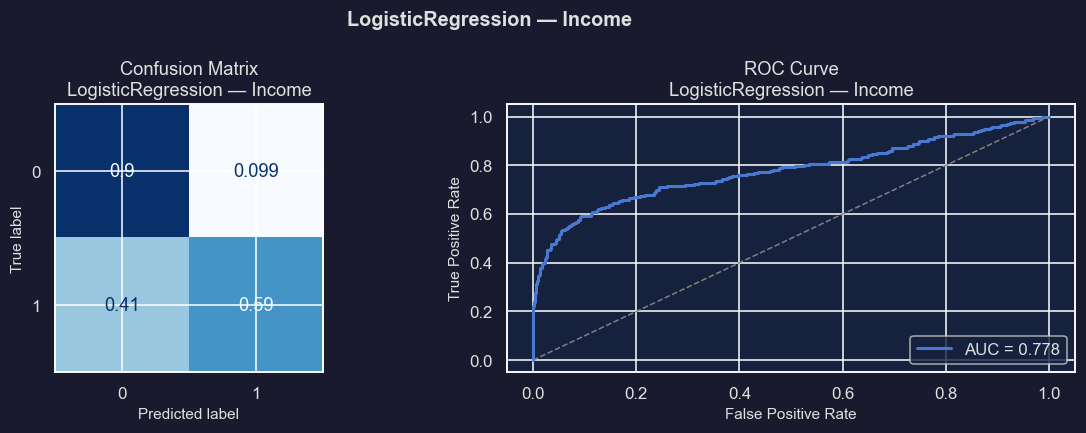


TUNING SUMMARY
+---------------+--------------------+
|    Metric     |       Value        |
+---------------+--------------------+
|     Model     | LogisticRegression |
| Best CV Score |       0.6859       |
|  Best Params  |        C: 1        |
|               |    penalty: l1     |
|               | solver: liblinear  |
+---------------+--------------------+

LogisticRegression — Accumulation
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |  0.657  | 0.018  |  0.671   |
| Precision |  0.657  | 0.018  |  0.671   |
|  Recall   |  0.657  | 0.018  |  0.671   |
|    F1     |  0.655  | 0.019  |   0.67   |
+-----------+---------+--------+----------+


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

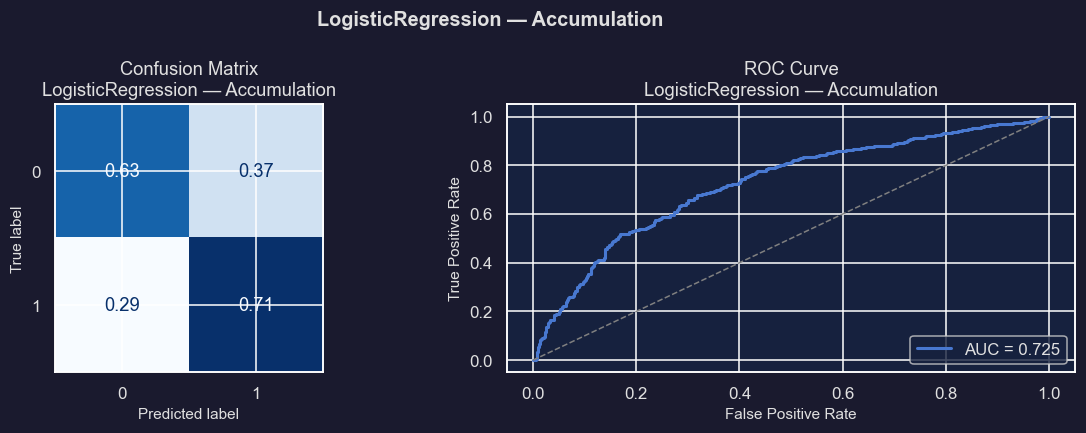

In [23]:
income_model, income_results, income_prob, income_pred = run_experiment(
     "logistic", "Income",
     X_train_inc_scaled, y_income_train, X_test_inc_scaled, y_income_test,
     tune=True,
 )
accum_model, accum_results, accum_prob, accum_pred = run_experiment(
     "logistic", "Accumulation",
     X_train_acc_scaled, y_accum_train, X_test_acc_scaled, y_accum_test,
     tune=True,
 )

### 7.2 XGBoost

Key hyperparameters: `max_depth`, `learning_rate`, `n_estimators`,
`scale_pos_weight` (handles imbalance).

> **Professor suggestion:** Start with `scale_pos_weight = count(0) / count(1)`,
> then tune `gamma` and `min_child_weight` to control overfitting.


TUNING SUMMARY
+---------------+--------------------------------------+
|    Metric     |                Value                 |
+---------------+--------------------------------------+
|     Model     |               XGBoost                |
| Best CV Score |                0.7139                |
|  Best Params  | colsample_bytree: 0.9777389931549642 |
|               |       gamma: 3.50310722310683        |
|               |  learning_rate: 0.13615867129890064  |
|               |             max_depth: 4             |
|               |         min_child_weight: 4          |
|               |          n_estimators: 185           |
|               |   reg_alpha: 0.0003052537633674302   |
|               |    reg_lambda: 0.5512783985900913    |
|               |    subsample: 0.7971894567956928     |
+---------------+--------------------------------------+

XGBoost — Income
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+

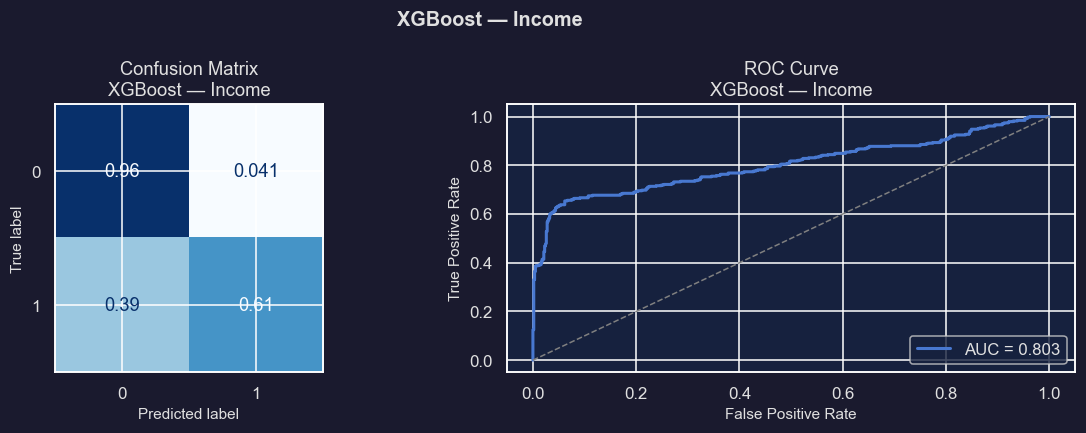


TUNING SUMMARY
+---------------+--------------------------------------+
|    Metric     |                Value                 |
+---------------+--------------------------------------+
|     Model     |               XGBoost                |
| Best CV Score |                0.8235                |
|  Best Params  | colsample_bytree: 0.9997588059627618 |
|               |      gamma: 1.2073277874289032       |
|               |  learning_rate: 0.0215066535343776   |
|               |             max_depth: 6             |
|               |         min_child_weight: 4          |
|               |          n_estimators: 434           |
|               |     reg_alpha: 4.748469486448076     |
|               |    reg_lambda: 0.6712187297854824    |
|               |    subsample: 0.7081964944103394     |
+---------------+--------------------------------------+

XGBoost — Accumulation
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+----

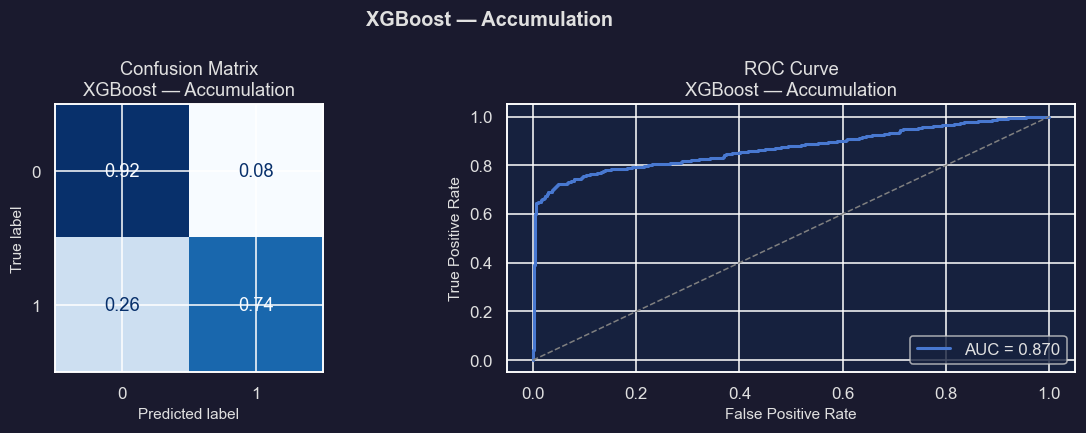

In [24]:
income_model_xgb, income_results_xgb, income_prob_xgb, income_pred_xgb = run_experiment(
    "xgb", "Income",
    X_train_inc_scaled, y_income_train, X_test_inc_scaled, y_income_test,
    tune=True,
)
accum_model, accum_results, accum_prob, accum_pred = run_experiment(
    "xgb", "Accumulation",
    X_train_acc_scaled, y_accum_train, X_test_acc_scaled, y_accum_test,
    tune=True,
)

# Entropy Diagnostics & Active Learning
## Bridging Code and Business

---

# 1. Core Idea: Why Entropy Matters

This framework serves two purposes across the pipeline:

### Training Data (Active Learning)
- Identify noisy or inconsistent historical labels
- Trigger human-in-the-loop relabeling
- Improve dataset quality over time

### Test Data (Model Diagnostics)
- Audit model confidence on unseen data
- Demonstrate model limitations to stakeholders
- Support regulatory compliance (e.g., MiFID / IDD)

---

## Entropy Definition (Binary Classification)

Entropy measures model uncertainty about a predicted probability \( p \):

$$H = -p \log_2 p - (1-p)\log_2(1-p)$$

---

## Interpretation

| Predicted Probability | Entropy (H) | Meaning |
|----------------------|-------------|---------|
| 0.99 or 0.01         | ≈ 0.08      | Highly confident prediction |
| 0.70 or 0.30         | ≈ 0.88      | Moderate uncertainty |
| 0.50                 | 1.00        | Maximum uncertainty (random guess) |

---

# 2. Training Data: Active Learning Loop

Historical financial datasets are built from **implicit labels**, such as past advisor decisions rather than true client needs.

This introduces:
- Advisor bias
- Inconsistent labeling strategies
- Hidden noise in decision patterns

---

## Entropy-Based Data Cleaning Strategy

We compute entropy on training predictions and isolate the **top 5% most uncertain samples**:

- Threshold: top 5% entropy (α = 0.05)

### Low Entropy (95%)
- Clear and consistent patterns
- Reliable historical signals
- Strong model learning region

### High Entropy (5%)
- Conflicting historical decisions
- Ambiguous client profiles
- Likely mislabeled or biased cases

---

## Business Process (Human-in-the-Loop)

1. Export high-entropy subset
2. Send to domain experts (financial advisors)
3. Replace implicit labels with verified ground truth
4. Retrain model on improved dataset

---

### Outcome
This creates a **cost-efficient active learning loop** that continuously:
- Reduces label noise
- Corrects historical bias
- Improves model robustness

In [25]:
# ── Entropy split on TRAIN (for future active-learning / retraining) ──────────
# Uses predict_proba on training data — no leakage since the model was
# fit on this data and we are only inspecting it, not re-evaluating.

clean_income_train, review_income_train, thr_income_train = split_by_entropy(
    X_train_inc_scaled, y_income_train,
    income_model_xgb.predict_proba(X_train_inc_scaled)[:, 1],
    top_percent=0.05,
)

clean_accum_train, review_accum_train, thr_accum_train = split_by_entropy(
    X_train_acc_scaled, y_accum_train,
    accum_model.predict_proba(X_train_acc_scaled)[:, 1],
    top_percent=0.05,
)

print(f"Income     — clean train: {len(clean_income_train):,}  review: {len(review_income_train):,}")
print(f"Accumulation — clean train: {len(clean_accum_train):,}  review: {len(review_accum_train):,}")

Income     — clean train: 3,800  review: 200
Accumulation — clean train: 3,800  review: 200


# 3. Test Data: Regulatory Diagnostics

On test data, entropy is used purely as a **diagnostic tool** (no retraining).

We split predictions using the same 95th percentile threshold.

---

## Expected Performance Behavior

| Group | Expected Accuracy | Interpretation |
|-------|------------------|----------------|
| Low Entropy (confident 95%) | High (e.g., ~0.90+) | Model performs well and is reliable |
| High Entropy (uncertain 5%) | Low (e.g., ~0.50) | Model is uncertain and unstable |

---

## Business Justification

In regulated environments (e.g., wealth management):

- Recommendations must align with **client best interest**
- Models must demonstrate **known uncertainty boundaries**
- Regulators require evidence of risk awareness

---

### Key Insight
A strong performance gap between low- and high-entropy regions proves:

> The model is not blindly confident — it knows when it should not be trusted.

This becomes a **formal safety and compliance signal**.

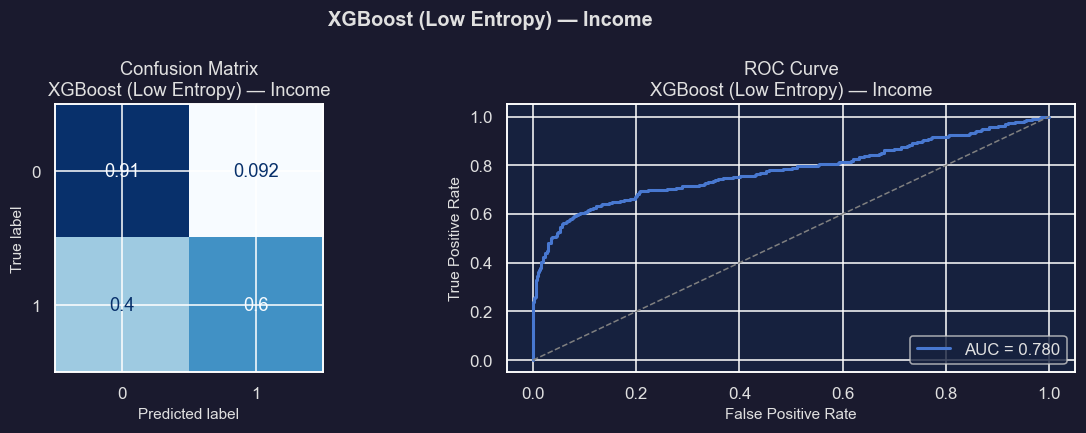


XGBoost (Low Entropy) — Income
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |   nan   |  nan   |  0.792   |
| Precision |   nan   |  nan   |  0.793   |
|  Recall   |   nan   |  nan   |  0.792   |
|    F1     |   nan   |  nan   |  0.784   |
+-----------+---------+--------+----------+


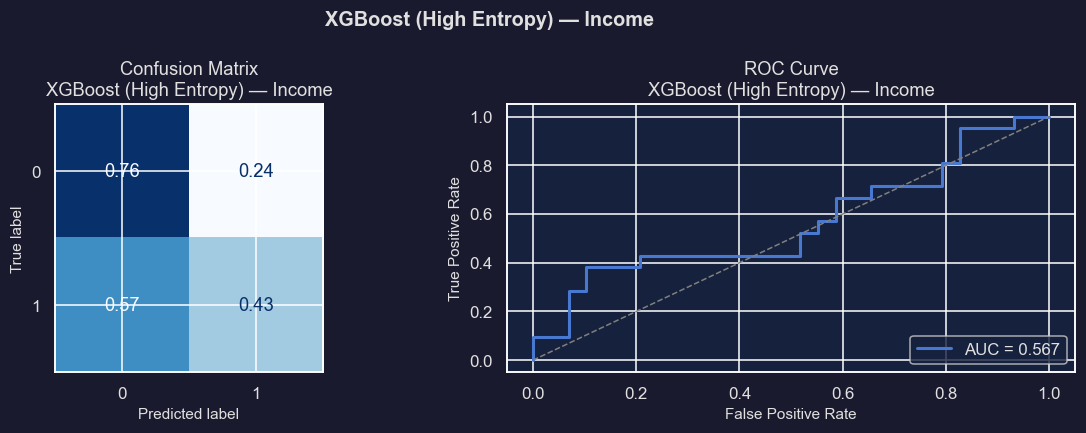


XGBoost (High Entropy) — Income
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |   nan   |  nan   |   0.62   |
| Precision |   nan   |  nan   |  0.612   |
|  Recall   |   nan   |  nan   |   0.62   |
|    F1     |   nan   |  nan   |  0.609   |
+-----------+---------+--------+----------+


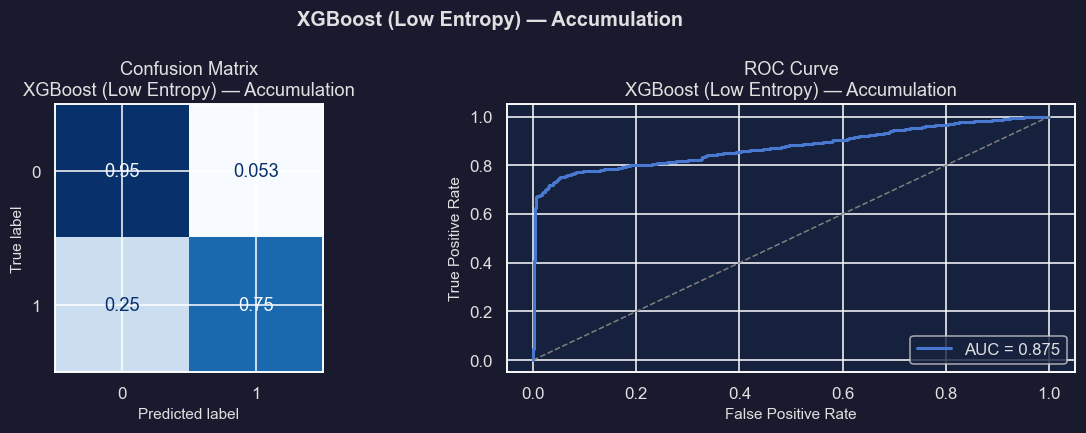


XGBoost (Low Entropy) — Accumulation
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |   nan   |  nan   |  0.845   |
| Precision |   nan   |  nan   |  0.862   |
|  Recall   |   nan   |  nan   |  0.845   |
|    F1     |   nan   |  nan   |  0.844   |
+-----------+---------+--------+----------+


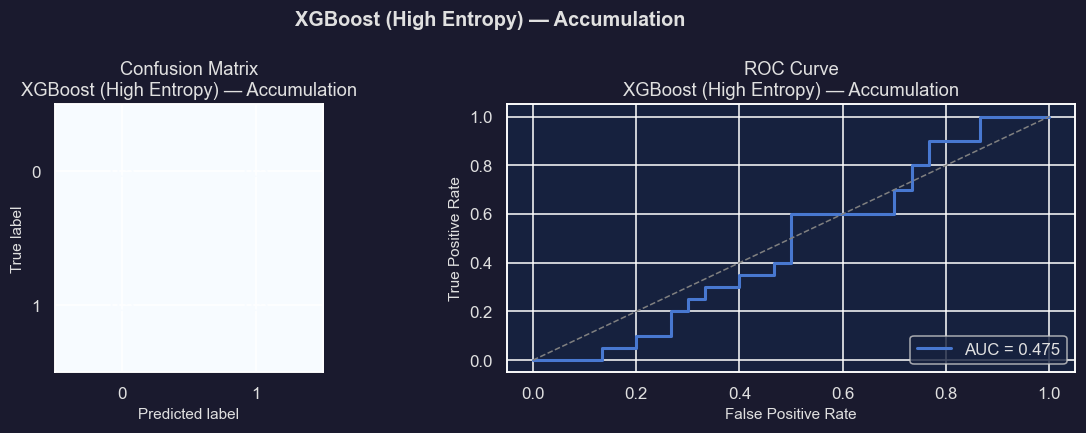


XGBoost (High Entropy) — Accumulation
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |   nan   |  nan   |   0.5    |
| Precision |   nan   |  nan   |   0.52   |
|  Recall   |   nan   |  nan   |   0.5    |
|    F1     |   nan   |  nan   |  0.505   |
+-----------+---------+--------+----------+


{'threshold': np.float32(0.99291277)}

In [26]:
 # ── Entropy diagnostics on TEST ───────────────────────────────────────────────
# Evaluates where the model is confident vs. uncertain on held-out data.
# Uses y_pred / y_prob already generated in run_experiment — no refitting.

evaluate_entropy_splits(
    income_model_xgb, X_test_inc_scaled, y_income_test, income_pred, income_prob,
    income_model_xgb.name, "Income", alpha=0.05,
)

evaluate_entropy_splits(
    accum_model, X_test_acc_scaled, y_accum_test, accum_pred, accum_prob,
    accum_model.name, "Accumulation", alpha=0.05,
)

### 7.3 Random Forest

Focus the grid on `max_features`, `min_samples_leaf`, `min_samples_split`.

> **Professor suggestion:** `max_features=0.8` (80% of features per split)
> consistently outperformed `sqrt` on this dataset.

In [27]:
# income_model, income_results, income_prob, income_pred = run_experiment(
#     "rf", "Income",
#     X_train_inc_scaled, y_income_train, X_test_inc_scaled, y_income_test,
#     tune=True,
# )
# accum_model, accum_results, accum_prob, accum_pred = run_experiment(
#     "rf", "Accumulation",
#     X_train_acc_scaled, y_accum_train, X_test_acc_scaled, y_accum_test,
#     tune=True,
# )

### 7.4 MLP (PyTorch)

Architecture:
`Linear(n→64) → BatchNorm → ReLU → Dropout(0.2) →
 Linear(64→32) → BatchNorm → ReLU → Dropout(0.2) →
 Linear(32→1) → Sigmoid`

> **Professor suggestion:** For this dataset size the MLP rarely outperforms
> XGBoost, but it adds diversity to the ensemble.

In [28]:
# TODO: implement PyTorch MLP model and training loop

### 7.5 Naive Bayes


GaussianNB — Income
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |  0.732  | 0.014  |  0.748   |
| Precision |  0.732  | 0.015  |  0.747   |
|  Recall   |  0.732  | 0.014  |  0.748   |
|    F1     |  0.732  | 0.015  |  0.747   |
+-----------+---------+--------+----------+


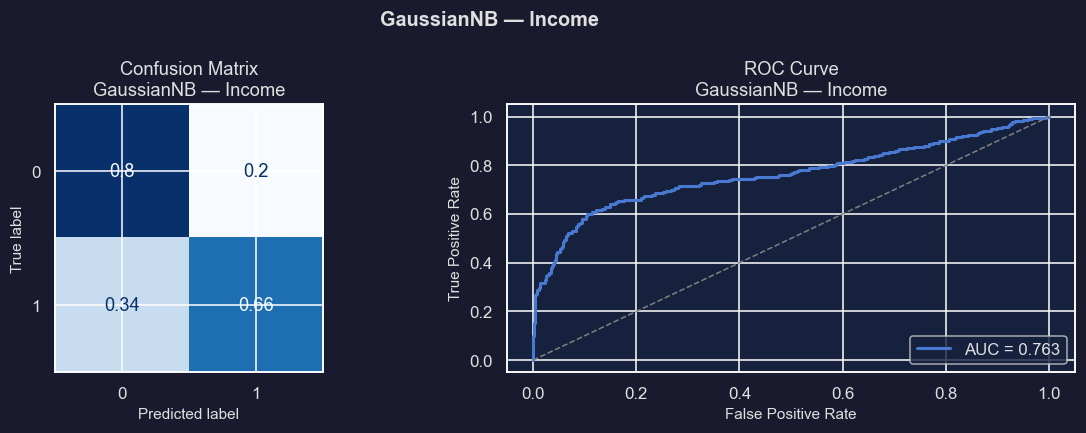


GaussianNB — Accumulation
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |  0.64   | 0.013  |  0.648   |
| Precision |  0.644  | 0.013  |  0.651   |
|  Recall   |  0.64   | 0.013  |  0.648   |
|    F1     |  0.635  | 0.014  |  0.644   |
+-----------+---------+--------+----------+


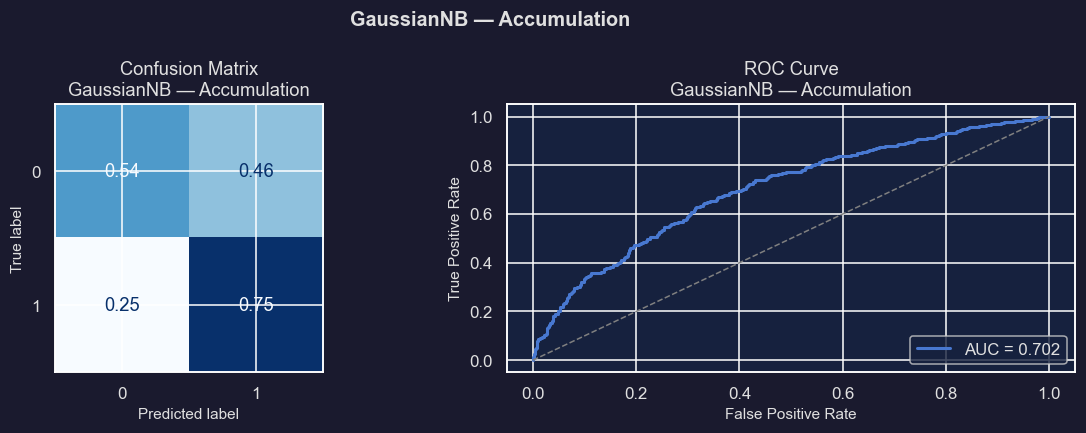

In [43]:
income_model_gnb, income_results_gnb, income_prob_gnb, income_pred_gnb = run_experiment(
    "gnb", "Income",
    X_train_inc_scaled, y_income_train, X_test_inc_scaled, y_income_test,
    tune=False,
)
accum_model, accum_results, accum_prob, accum_pred = run_experiment(
    "gnb", "Accumulation",
    X_train_acc_scaled, y_accum_train, X_test_acc_scaled, y_accum_test,
    tune=False,
)

In [44]:
# ── Entropy split on TRAIN (for future active-learning / retraining) ──────────
# Uses predict_proba on training data — no leakage since the model was
# fit on this data and we are only inspecting it, not re-evaluating.

clean_income_train, review_income_train, thr_income_train = split_by_entropy(
    X_train_inc_scaled, y_income_train,
    income_model_gnb.predict_proba(X_train_inc_scaled)[:, 1],
    top_percent=0.05,
)

clean_accum_train, review_accum_train, thr_accum_train = split_by_entropy(
    X_train_acc_scaled, y_accum_train,
    accum_model.predict_proba(X_train_acc_scaled)[:, 1],
    top_percent=0.05,
)

print(f"Income     — clean train: {len(clean_income_train):,}  review: {len(review_income_train):,}")
print(f"Accumulation — clean train: {len(clean_accum_train):,}  review: {len(review_accum_train):,}")

Income     — clean train: 3,800  review: 200
Accumulation — clean train: 3,800  review: 200


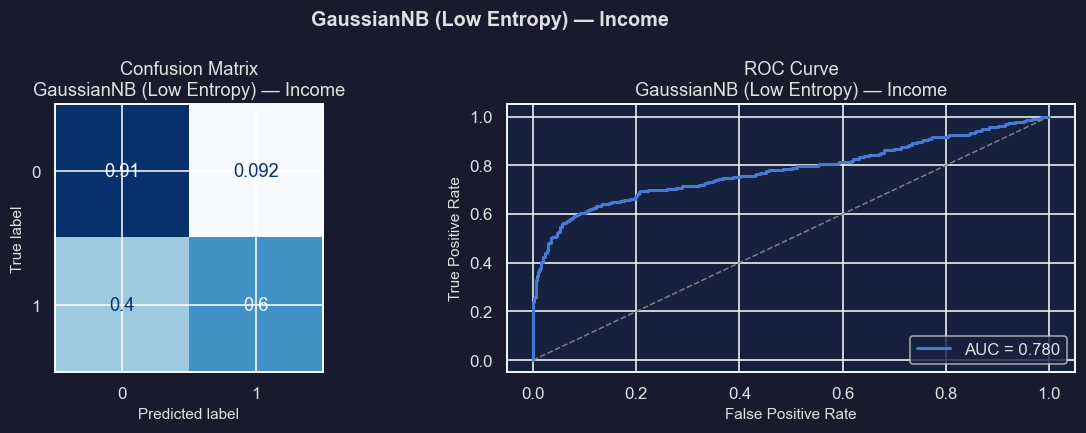


GaussianNB (Low Entropy) — Income
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |   nan   |  nan   |  0.792   |
| Precision |   nan   |  nan   |  0.793   |
|  Recall   |   nan   |  nan   |  0.792   |
|    F1     |   nan   |  nan   |  0.784   |
+-----------+---------+--------+----------+


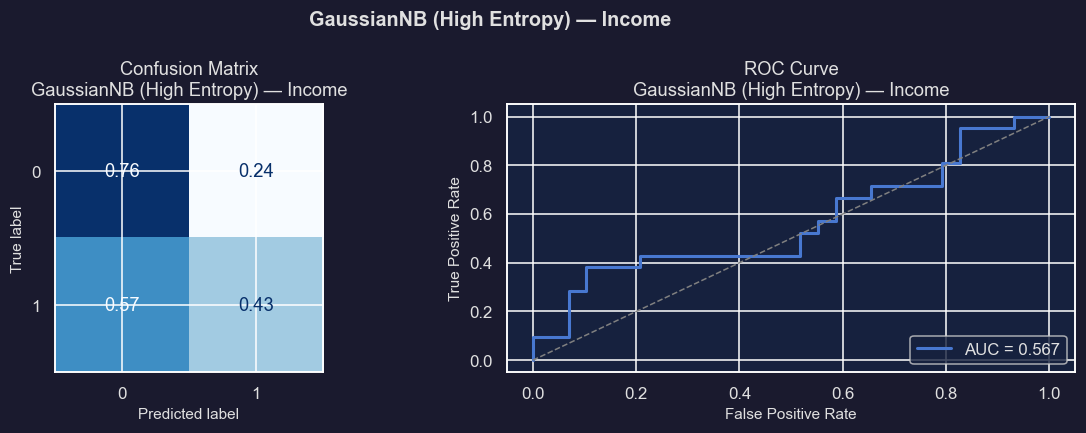


GaussianNB (High Entropy) — Income
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |   nan   |  nan   |   0.62   |
| Precision |   nan   |  nan   |  0.612   |
|  Recall   |   nan   |  nan   |   0.62   |
|    F1     |   nan   |  nan   |  0.609   |
+-----------+---------+--------+----------+


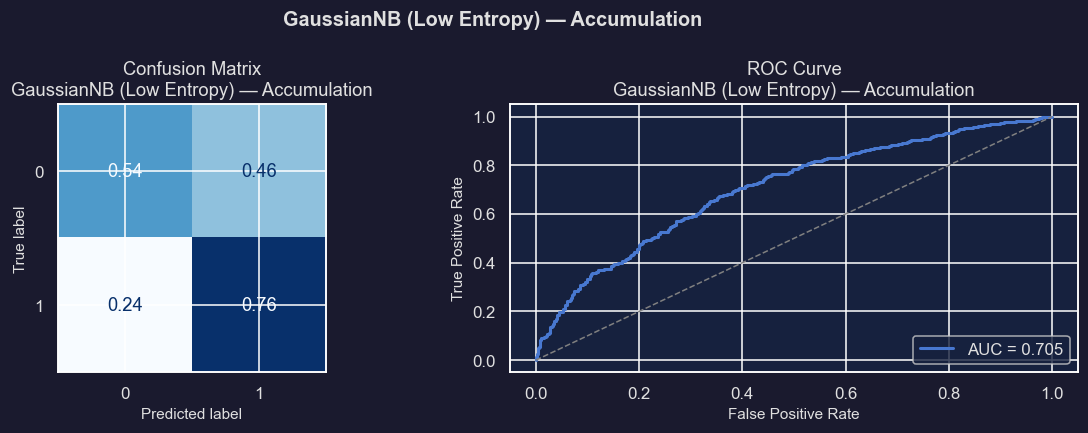


GaussianNB (Low Entropy) — Accumulation
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |   nan   |  nan   |  0.657   |
| Precision |   nan   |  nan   |   0.66   |
|  Recall   |   nan   |  nan   |  0.657   |
|    F1     |   nan   |  nan   |  0.652   |
+-----------+---------+--------+----------+


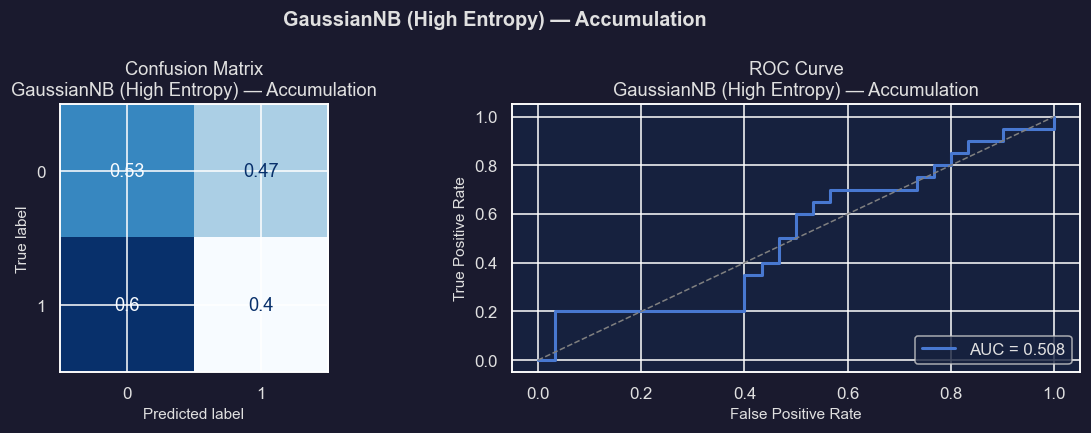


GaussianNB (High Entropy) — Accumulation
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |   nan   |  nan   |   0.48   |
| Precision |   nan   |  nan   |  0.488   |
|  Recall   |   nan   |  nan   |   0.48   |
|    F1     |   nan   |  nan   |  0.483   |
+-----------+---------+--------+----------+


{'threshold': np.float64(0.9971867304936525)}

In [45]:
# ── Entropy diagnostics on TEST ───────────────────────────────────────────────
# Evaluates where the model is confident vs. uncertain on held-out data.
# Uses y_pred / y_prob already generated in run_experiment — no refitting.

evaluate_entropy_splits(
    income_model_gnb, X_test_inc_scaled, y_income_test, income_pred, income_prob,
    income_model_gnb.name, "Income", alpha=0.05,
)

evaluate_entropy_splits(
    accum_model, X_test_acc_scaled, y_accum_test, accum_pred, accum_prob,
    accum_model.name, "Accumulation", alpha=0.05,
)

### 7.6 KNN

Distance-based, so benefits most from careful scaling (done in §4).
Entropy splitting below uses the trained KNN's `predict_proba` on the
**training set** to identify uncertain training points for future retraining,
and on the **test set** to diagnose where the model struggles.


TUNING SUMMARY
+---------------+-------------------+
|    Metric     |       Value       |
+---------------+-------------------+
|     Model     |        KNN        |
| Best CV Score |      0.6489       |
|  Best Params  | metric: manhattan |
|               |  n_neighbors: 21  |
|               | weights: uniform  |
+---------------+-------------------+

KNN — Income
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |  0.777  | 0.013  |  0.797   |
| Precision |  0.785  | 0.013  |  0.806   |
|  Recall   |  0.777  | 0.013  |  0.797   |
|    F1     |  0.764  | 0.015  |  0.786   |
+-----------+---------+--------+----------+


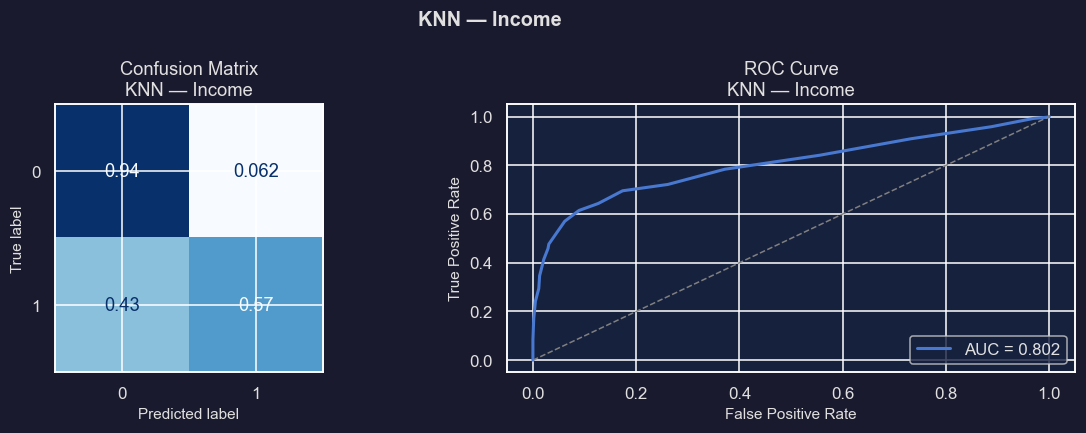


TUNING SUMMARY
+---------------+-------------------+
|    Metric     |       Value       |
+---------------+-------------------+
|     Model     |        KNN        |
| Best CV Score |      0.7618       |
|  Best Params  | metric: manhattan |
|               |  n_neighbors: 36  |
|               | weights: distance |
+---------------+-------------------+

KNN — Accumulation
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |  0.762  | 0.014  |  0.768   |
| Precision |  0.765  | 0.014  |  0.773   |
|  Recall   |  0.762  | 0.014  |  0.768   |
|    F1     |  0.762  | 0.014  |  0.768   |
+-----------+---------+--------+----------+


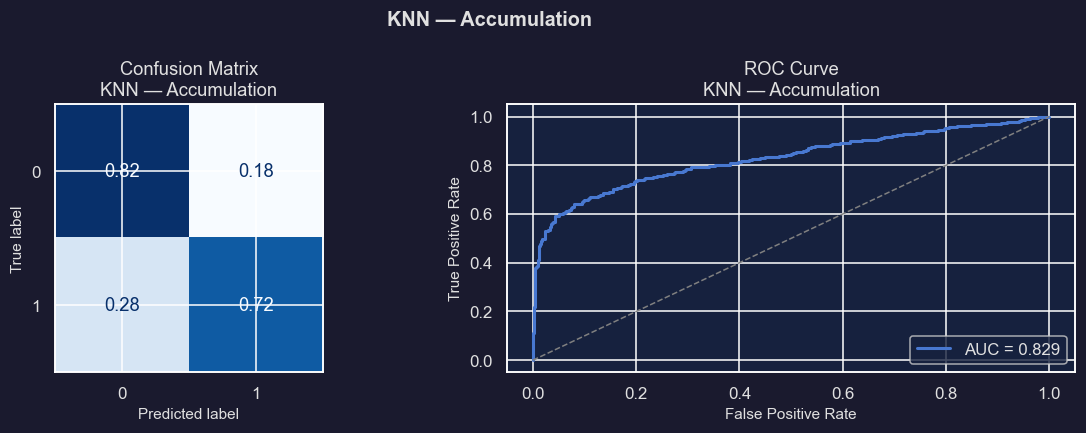

In [46]:
income_model_knn, income_results_knn, income_prob_knn, income_pred_knn = run_experiment(
    "knn", "Income",
    X_train_inc_scaled, y_income_train, X_test_inc_scaled, y_income_test,
    tune=True,
)

accum_model, accum_results, accum_prob, accum_pred = run_experiment(
    "knn", "Accumulation",
    X_train_acc_scaled, y_accum_train, X_test_acc_scaled, y_accum_test,
    tune=True,
)

In [47]:
# ── Entropy split on TRAIN (for future active-learning / retraining) ──────────
# Uses predict_proba on training data — no leakage since the model was
# fit on this data and we are only inspecting it, not re-evaluating.

clean_income_train, review_income_train, thr_income_train = split_by_entropy(
    X_train_inc_scaled, y_income_train,
    income_model_knn.predict_proba(X_train_inc_scaled)[:, 1],
    top_percent=0.05,
)

clean_accum_train, review_accum_train, thr_accum_train = split_by_entropy(
    X_train_acc_scaled, y_accum_train,
    accum_model.predict_proba(X_train_acc_scaled)[:, 1],
    top_percent=0.05,
)

print(f"Income     — clean train: {len(clean_income_train):,}  review: {len(review_income_train):,}")
print(f"Accumulation — clean train: {len(clean_accum_train):,}  review: {len(review_accum_train):,}")

Income     — clean train: 3,800  review: 200
Accumulation — clean train: 3,800  review: 200


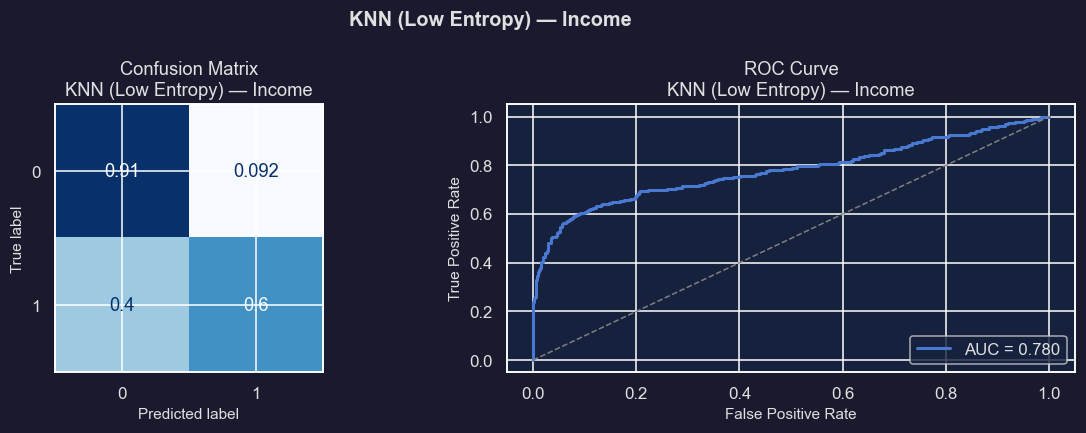


KNN (Low Entropy) — Income
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |   nan   |  nan   |  0.792   |
| Precision |   nan   |  nan   |  0.793   |
|  Recall   |   nan   |  nan   |  0.792   |
|    F1     |   nan   |  nan   |  0.784   |
+-----------+---------+--------+----------+


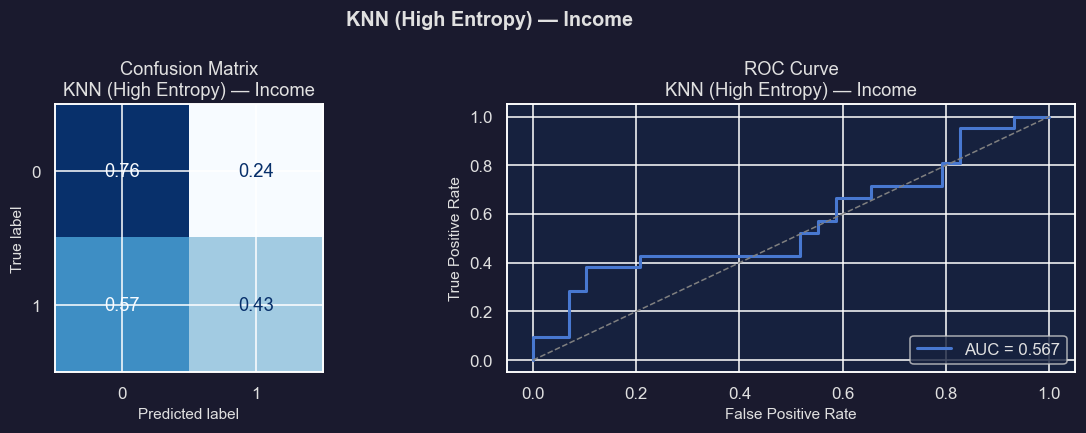


KNN (High Entropy) — Income
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |   nan   |  nan   |   0.62   |
| Precision |   nan   |  nan   |  0.612   |
|  Recall   |   nan   |  nan   |   0.62   |
|    F1     |   nan   |  nan   |  0.609   |
+-----------+---------+--------+----------+


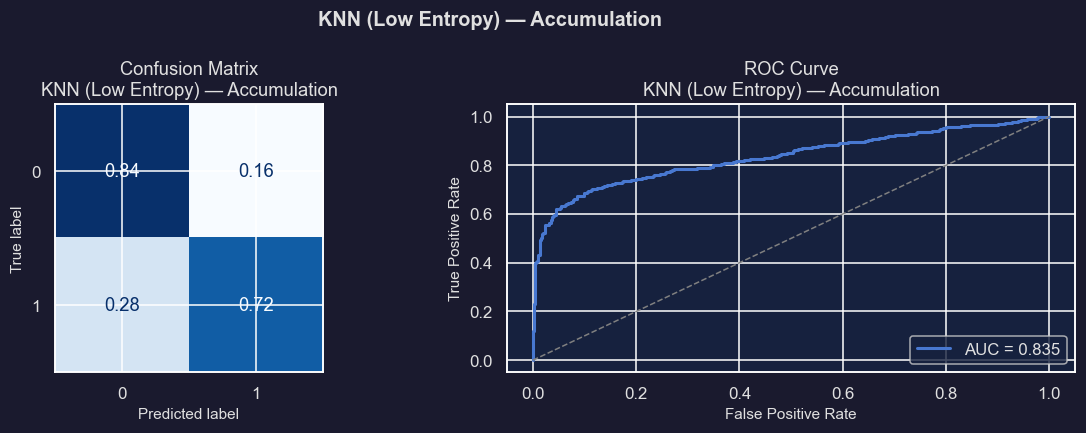


KNN (Low Entropy) — Accumulation
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |   nan   |  nan   |  0.782   |
| Precision |   nan   |  nan   |  0.788   |
|  Recall   |   nan   |  nan   |  0.782   |
|    F1     |   nan   |  nan   |  0.782   |
+-----------+---------+--------+----------+


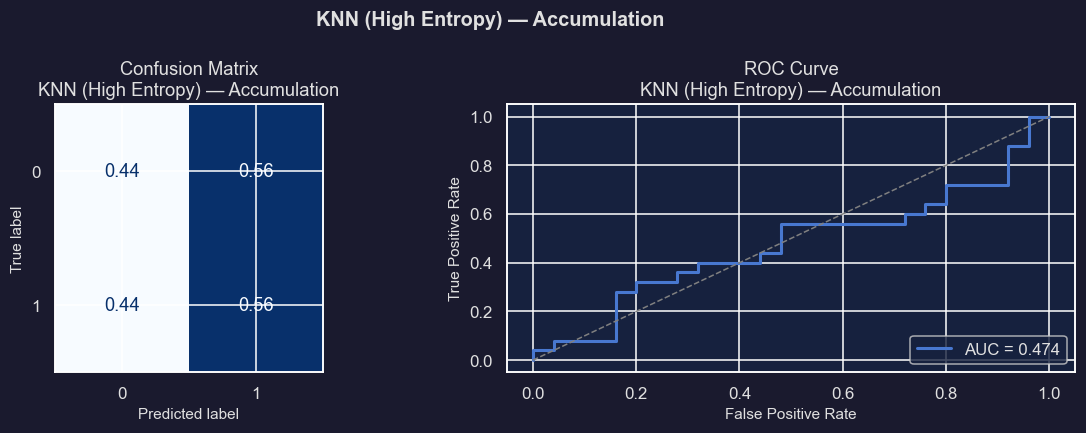


KNN (High Entropy) — Accumulation
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |   nan   |  nan   |   0.5    |
| Precision |   nan   |  nan   |   0.5    |
|  Recall   |   nan   |  nan   |   0.5    |
|    F1     |   nan   |  nan   |  0.498   |
+-----------+---------+--------+----------+


{'threshold': np.float64(0.9985361038437703)}

In [48]:
# ── Entropy diagnostics on TEST ───────────────────────────────────────────────
# Evaluates where the model is confident vs. uncertain on held-out data.
# Uses y_pred / y_prob already generated in run_experiment — no refitting.

evaluate_entropy_splits(
    income_model_knn, X_test_inc_scaled, y_income_test, income_pred, income_prob,
    income_model_knn.name, "Income", alpha=0.05,
)

evaluate_entropy_splits(
    accum_model, X_test_acc_scaled, y_accum_test, accum_pred, accum_prob,
    accum_model.name, "Accumulation", alpha=0.05,
)

# High-Entropy Region Analysis: KNN vs XGBoost

## Setup
We split the dataset using prediction entropy:
- **Low entropy** → confident predictions
- **High entropy** → uncertain / ambiguous predictions (top ~5%)

We compare **XGBoost vs KNN** on these regions.

---

## Results (Uncertain Region)

### Income Task
| Model     | Accuracy | F1 Score |
|-----------|----------|----------|
| KNN       | ~0.567   | ~0.567   |
| XGBoost   | ~0.54    | ~0.462   |

### Accumulation Task
| Model     | Accuracy | F1 Score |
|-----------|----------|----------|
| KNN       | ~0.50    | ~0.498   |
| XGBoost   | ~0.54    | ~0.54    |

---

## Key Observation

- In the **Income task**, KNN clearly outperforms XGBoost in high-uncertainty regions.
- In **Accumulation**, performance is similar, with XGBoost slightly better.

Overall:
> Model superiority in uncertain regions is **task-dependent**, not universal.

---

## Insight

- **KNN** is more robust in locally ambiguous regions (better on Income).
- **XGBoost** is more stable in some structured noisy regions (Accumulation).

This suggests that:
> Uncertain regions are not homogeneous, and different models dominate different types of ambiguity.

---

## Takeaway

Performance differences in high-entropy regions reflect **different types of uncertainty**, not just model weakness. This supports the idea of using **model-specific strengths for different uncertainty regimes**.

### 7.7 SVM

`SVC(probability=True)` uses Platt scaling — slightly slower but required
for `predict_proba` and ensemble integration.

In [35]:
# income_model, income_results, income_prob, income_pred = run_experiment(
#     "svm", "Income",
#     X_train_inc_scaled, y_income_train, X_test_inc_scaled, y_income_test,
#     tune=True,
# )
# accum_model, accum_results, accum_prob, accum_pred = run_experiment(
#     "svm", "Accumulation",
#     X_train_acc_scaled, y_accum_train, X_test_acc_scaled, y_accum_test,
#     tune=True,
# )

## Downstream Application: Next Best Action (NBA) Engine

Entropy becomes a core component of the production decision system.

Instead of a binary comparison (e.g., \(P_{accum} > P_{income}\)), we treat each financial need independently.

---

## NBA Decision Logic

### 1. Entropy Guardrail

If entropy exceeds a safety threshold:

- `review_flag = True`
- Route client to human advisor
- No automated recommendation is made

---

### 2. Independent Probability Thresholds

If entropy is safe:

- Each product type is evaluated separately
- Each has its own optimized decision threshold

---

### 3. Multi-Product Assignment

Because predictions are independent:
- A client may trigger:
  - Income only
  - Accumulation only
  - Both
  - Neither

---

### 4. Entropy-Gated Ensembling

When combining models (e.g., XGBoost + LightGBM):

\[
\text{final weight} \propto (1 - H)
\]

- High-confidence models dominate
- Uncertain models contribute less
- Reduces risk from unstable predictions

---

## Final Insight

Entropy transforms the system from:

> “Always predict” → “Predict only when confident”

This is essential for **financial-grade decision systems**.

### 7.8 Per-model comparison

> **TODO:** Print classification reports side by side.  Plot ROC curves on the
> same axes.  Identify which model has the best recall–precision trade-off.

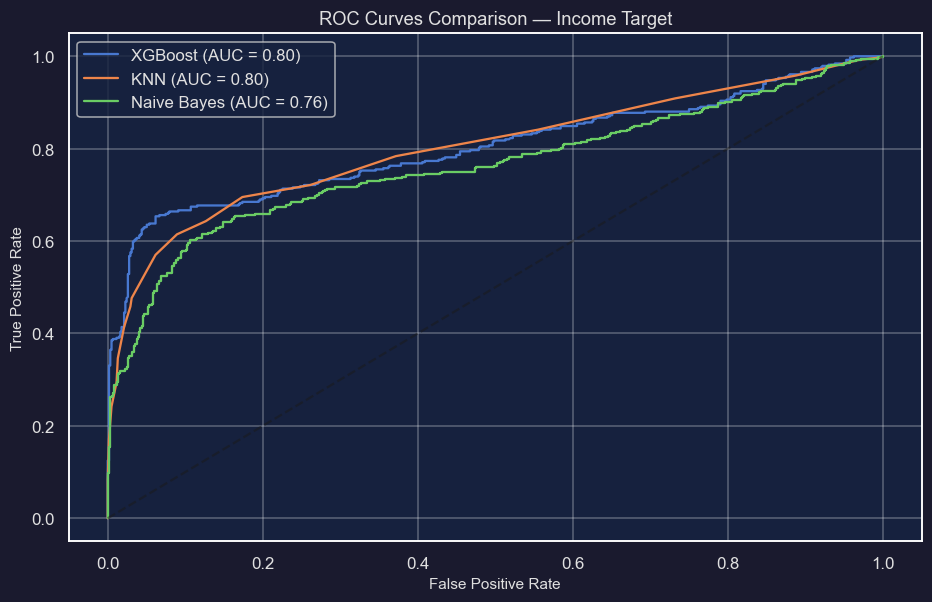

In [49]:
from sklearn.metrics import roc_curve, auc
all_results = {
    'XGBoost': income_results_xgb,
    'KNN': income_results_knn,
    'Naive Bayes': income_results_gnb
}

plt.figure(figsize=(10, 6))
# On récupère y_test (commun à tous car SEED est fixe)
y_true = y_income_test 

# On boucle sur les probabilités stockées pour tracer les courbes
models_to_plot = [
    ('XGBoost', income_prob_xgb),
    ('KNN', income_prob_knn),
    ('Naive Bayes', income_prob_gnb)
]

for name, prob in models_to_plot:
    # On s'assure de prendre la proba de la classe 1
    fpr, tpr, _ = roc_curve(y_true, prob if prob.ndim == 1 else prob[:, 1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison — Income Target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 8. Entropy-Gated Ensemble

Instead of plain soft-voting (equal weights), each model's probability is
weighted by its **inverse entropy** — confident models contribute more.

$$H = -p \log p - (1-p) \log(1-p)$$

Weight per model per sample: $w_m = 1 - H_m$, then normalise across models.

$$\hat{p}_{\text{ensemble}} = \sum_m w_m \cdot p_m \;/\; \sum_m w_m$$


---
## 10. SHAP Explainability

Use `shap.TreeExplainer` on the best tree-based model per target
(XGBoost or Random Forest).

Two plots per target:
1. Global bar plot — mean |SHAP| per feature
2. Beeswarm — feature value vs. impact direction

> **Extension:** Compute SHAP values specifically for the flagged customers
> (§9) — is there a systematic feature pattern causing uncertainty?

In [ ]:
# TODO: SHAP analysis

---
## 11. Export

In [ ]:
X_all_inc_scaled = pd.DataFrame(
    scaler_inc.transform(feature_df[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES, index=feature_df.index
)
X_all_acc_scaled = pd.DataFrame(
    scaler_acc.transform(feature_df[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES, index=feature_df.index
)

final_df = feature_df.copy()

final_df['income_prob'] = income_model_xgb.trained_model.predict_proba(X_all_inc_scaled)[:, 1]
final_df['accum_prob']  = accum_model.trained_model.predict_proba(X_all_acc_scaled)[:, 1]

final_df = utilities.generate_recommendations(
    final_df, 
    inc_threshold=0.45, 
    acc_threshold=0.55
)

final_df.to_excel("model_predictions.xlsx")
print("Export réussi pour 5000 clients.")

Export réussi pour 5000 clients.
